<a href="https://colab.research.google.com/github/siuyin/image_rotation_correction/blob/main/Image_rotation_correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Given** that I have a camera,  
and a mostly stationery scene  
and I capture an image with the camera  
and I define this image to be the reference image, R.  
**When** the camera is moved on a horizontal plane and/or rotated on any or all of its 3 axes, the camera will then capture a different but similar image, I.  
**Then** I should get a report on how to rotate image I to be most similar to the reference image R.

The code below returns exactly **one number** representing that single, best correction angle in degrees.

In [21]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


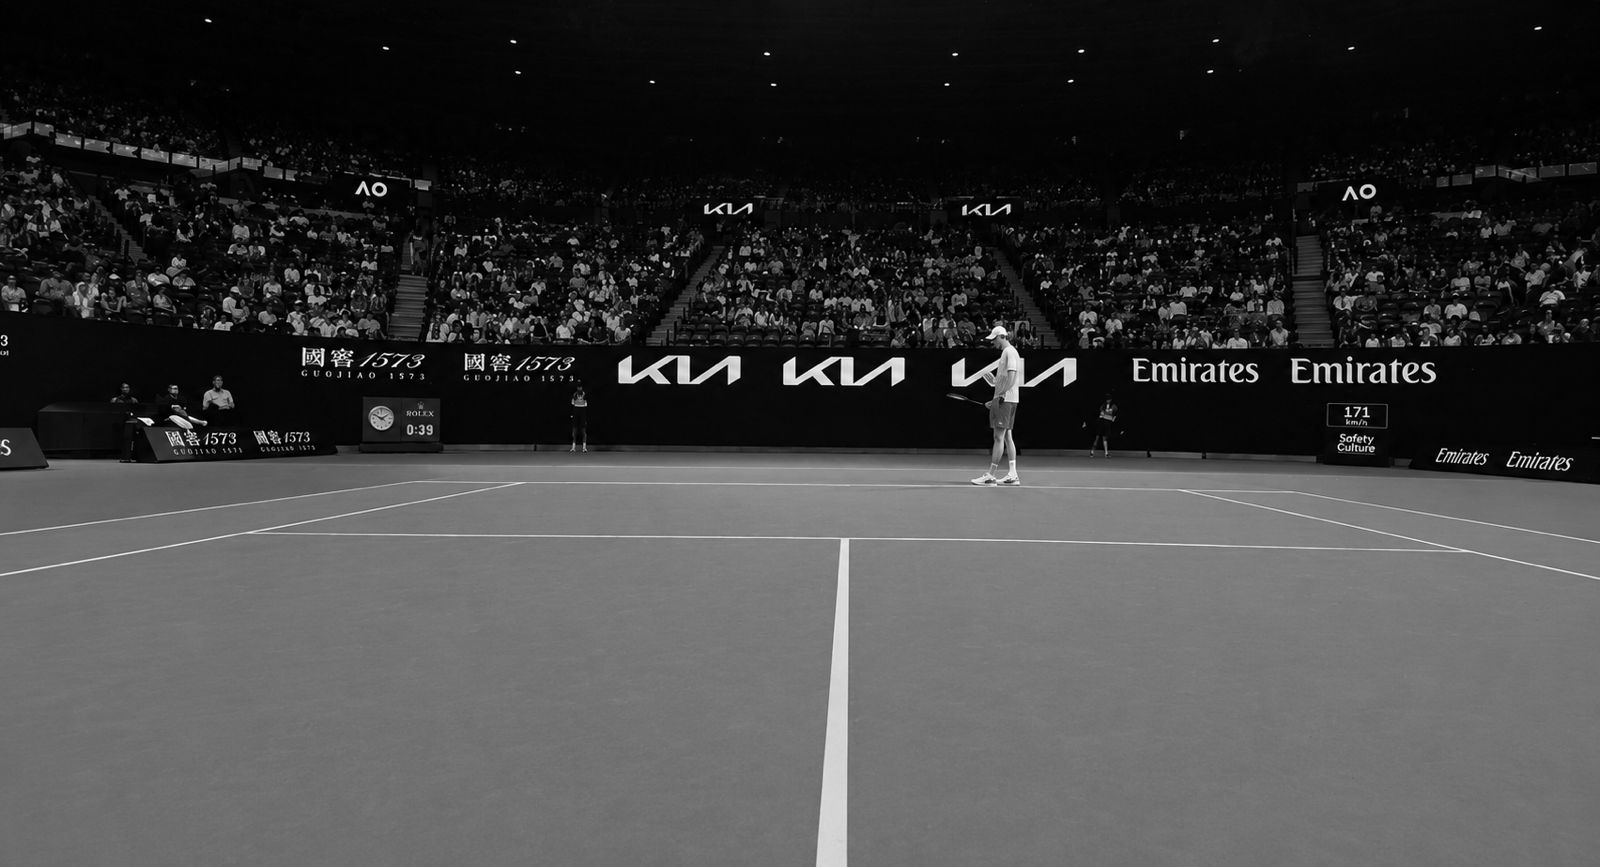

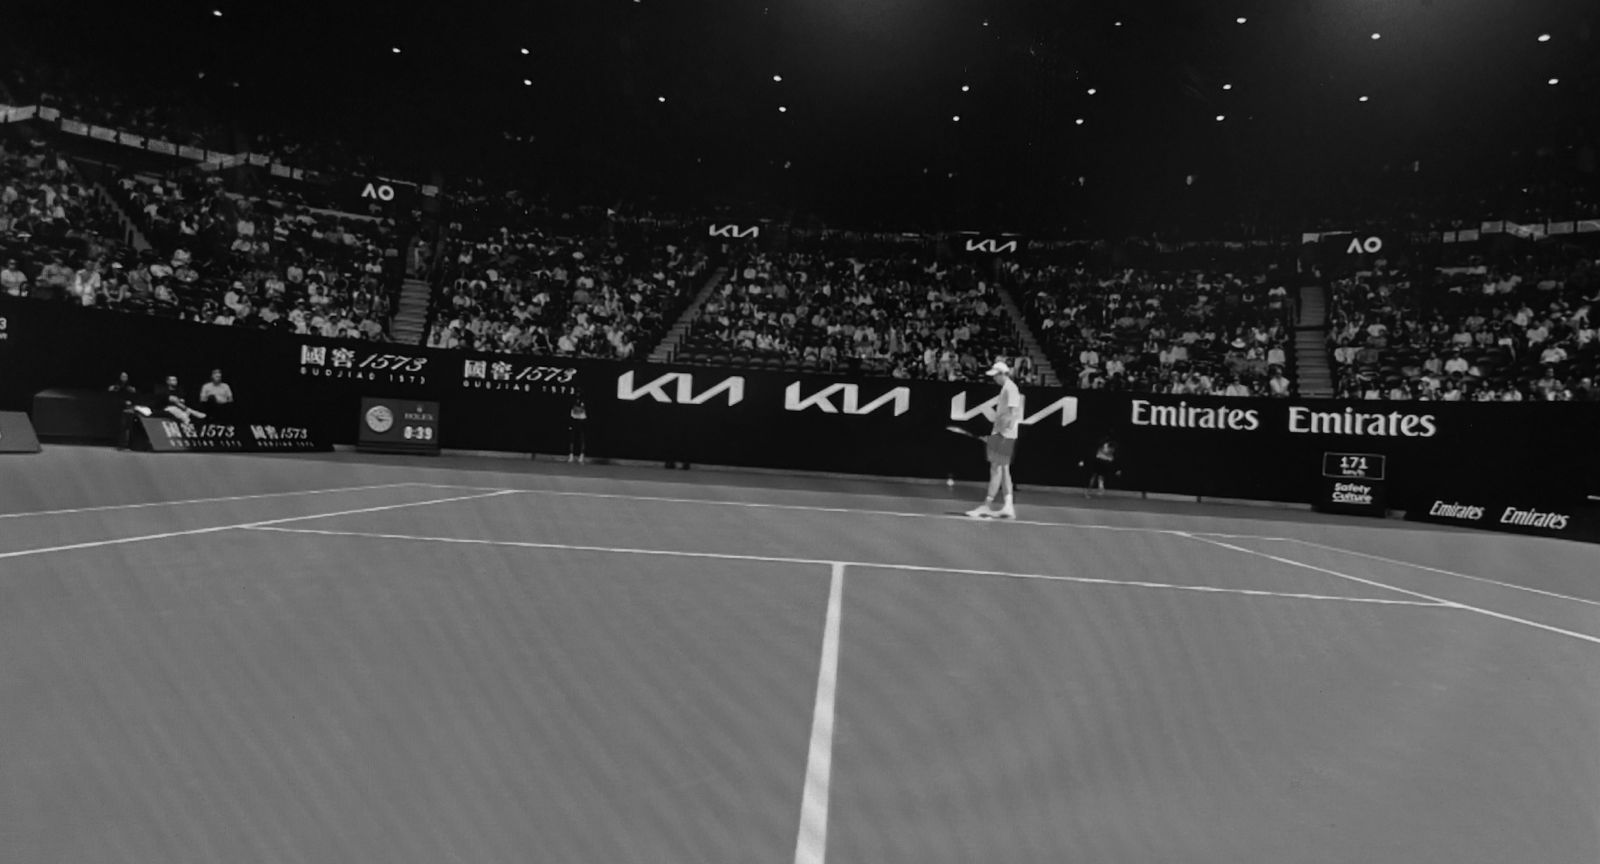

Correction Rotation Required: 1.20°


In [22]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def extract_orb_features(img_ref, img_src):
    """Detects features and computes descriptors using ORB."""
    orb = cv2.ORB_create(nfeatures=3000)
    kp_ref, des_ref = orb.detectAndCompute(img_ref, None)
    kp_src, des_src = orb.detectAndCompute(img_src, None)
    if des_ref is None or des_src is None:
        raise ValueError("Could not extract features from one or both images.")
    return kp_ref, des_ref, kp_src, des_src

def match_feature_points(kp_ref, des_ref, kp_src, des_src):
    """Matches points between images and extracts 2D pixel coordinates."""
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = sorted(bf.match(des_ref, des_src), key=lambda x: x.distance)
    if len(matches) < 8:
        raise ValueError(f"Insufficient feature matches found ({len(matches)}/8).")
    pts_ref = np.float32([kp_ref[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    pts_src = np.float32([kp_src[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
    return pts_ref, pts_src

def estimate_intrinsic_matrix(img):
    """Constructs a basic camera matrix using image width as a focal heuristic."""
    h, w = img.shape[:2]
    focal_length = w
    center_x, center_y = w / 2, h / 2
    return np.array([
        [focal_length, 0, center_x],
        [0, focal_length, center_y],
        [0, 0, 1]
    ], dtype=np.float32)

def extract_roll_correction(pts_ref, pts_src, K):
    """Finds Essential Matrix via RANSAC and extracts the single roll correction angle."""
    E, mask = cv2.findEssentialMat(
        pts_src, pts_ref, K, method=cv2.RANSAC, prob=0.999, threshold=1.0
    )
    inliers_src = pts_src[mask.ravel() == 1]
    inliers_ref = pts_ref[mask.ravel() == 1]
    _, R, _, _ = cv2.recoverPose(E, inliers_src, inliers_ref, K)

    # Calculate Roll (rotation around the camera's optical Z-axis)
    roll_rad = np.arctan2(R[2, 1], R[2, 2])
    return np.degrees(roll_rad)

def get_single_correction_angle(img_ref, img_src):
    """Orchestrates pipeline to output the singular required 2D rotation angle."""
    kp_r, des_r, kp_s, des_s = extract_orb_features(img_ref, img_src)
    pts_r, pts_s = match_feature_points(kp_r, des_r, kp_s, des_s)
    K = estimate_intrinsic_matrix(img_ref)

    return extract_roll_correction(pts_r, pts_s, K)

# --- Verification Entry Point ---
if __name__ == "__main__":
    img_R = cv2.imread('/content/drive/MyDrive/rotated_image/ref.jpg', cv2.IMREAD_GRAYSCALE)
    img_A = cv2.imread('/content/drive/MyDrive/rotated_image/imgA.jpg', cv2.IMREAD_GRAYSCALE)
    # img_B = cv2.imread('/content/drive/MyDrive/rotated_image/imgB.jpg', cv2.IMREAD_GRAYSCALE)
    cv2_imshow(img_R)
    cv2_imshow(img_A)
    # cv2_imshow(img_B)


    #if img_R is not None and img_A is not None and img_B is not None:
    if img_R is not None and img_A is not None:
        try:
            correction_angle_a = get_single_correction_angle(img_R, img_A)
            #correction_angle_b = get_single_correction_angle(img_R, img_B)
            #print(f"Correction Rotations Required: {correction_angle_a:.2f}°, {correction_angle_b:.2f}°")
            print(f"Correction Rotation Required: {correction_angle_a:.2f}°")
        except Exception as e:
            print(f"Pipeline error: {e}")